<a href="https://colab.research.google.com/github/kousik2006/Titanic-Survival-prediction/blob/main/Titanic_without_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [264]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [265]:
df = pd.read_csv("/content/drive/MyDrive/100 days of ML/Day 29 :- PIpelining/train.csv")

## UNDERSTANDING THE DATA

In [266]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
708,709,1,1,"Cleaver, Miss. Alice",female,22.0,0,0,113781,151.5500,NaN,S
573,574,1,3,"Kelly, Miss. Mary",female,NaN,0,0,14312,7.7500,NaN,Q
731,732,0,3,"Hassan, Mr. Houssein G N",male,11.0,0,0,2699,18.7875,NaN,C
765,766,1,1,"Hogeboom, Mrs. John C (Anna Andrews)",female,51.0,1,0,13502,77.9583,D11,S
150,151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.5250,NaN,S


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [268]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [269]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [270]:
df.duplicated().sum()

np.int64(0)

In [271]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [272]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [274]:
df.drop(columns=["PassengerId","Name","Ticket","Cabin"], inplace=True)

In [275]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


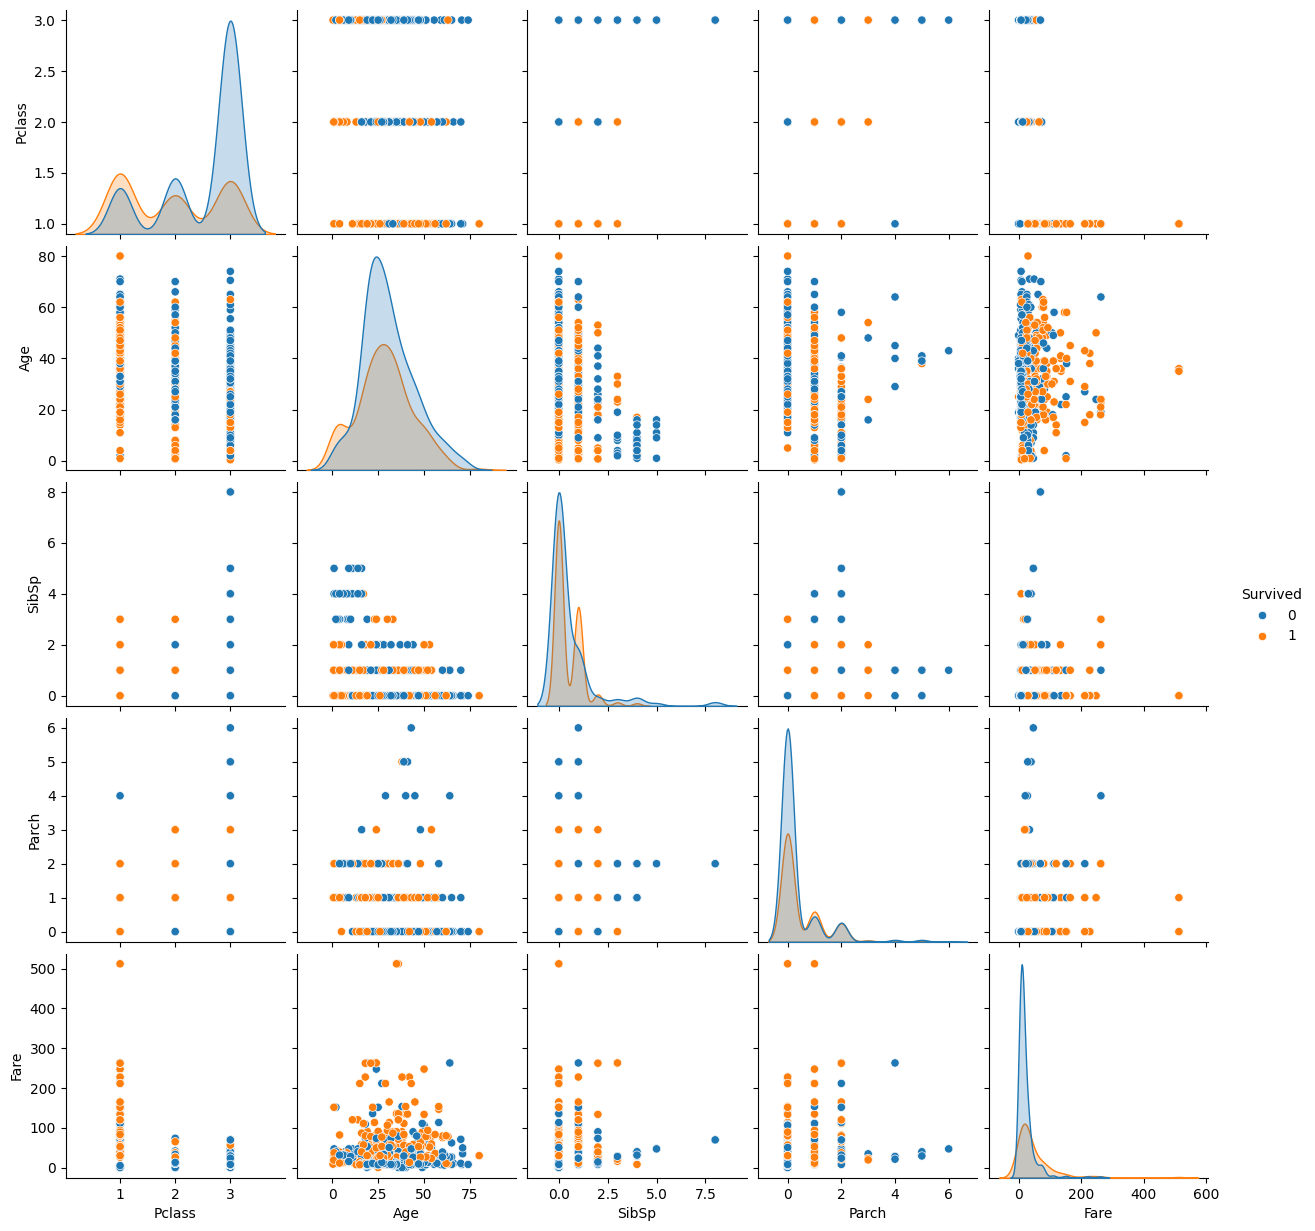

In [276]:
sns.pairplot(df,hue="Survived")

<Axes: xlabel='Survived', ylabel='Sex'>

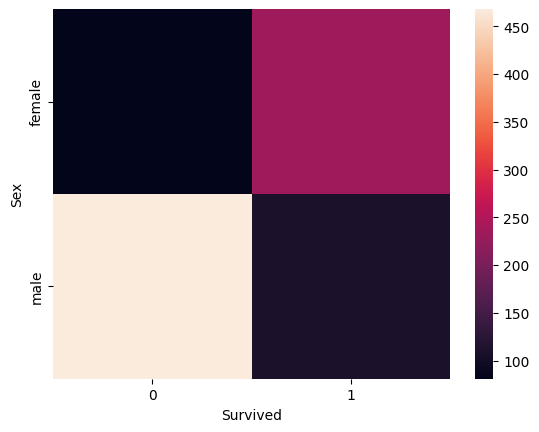

In [277]:
sns.heatmap(pd.crosstab(df['Sex'],df['Survived']))

In [278]:
pd.crosstab(df['Sex'],df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


## train test spirit

In [279]:
x= df.drop(columns=["Survived"])

In [280]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [281]:
y = df["Survived"]

In [282]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [283]:
x.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [284]:
y.isnull().sum()

np.int64(0)

In [285]:
from sklearn.model_selection import train_test_split

In [286]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state= 42, stratify= y
)

In [287]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
692,3,male,NaN,0,0,56.4958,S
481,2,male,NaN,0,0,0.0000,S
527,1,male,NaN,0,0,221.7792,S
855,3,female,18.0,0,1,9.3500,S
801,2,female,31.0,1,1,26.2500,S


In [288]:
x_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.1500,S
160,3,male,44.0,0,1,16.1000,S
553,3,male,22.0,0,0,7.2250,C
860,3,male,41.0,2,0,14.1083,S
241,3,female,NaN,1,0,15.5000,Q


In [289]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 712 entries, 692 to 507
Series name: Survived
Non-Null Count  Dtype
--------------  -----
712 non-null    int64
dtypes: int64(1)
memory usage: 11.1 KB


In [290]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    object 
 2   Age       575 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  710 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 44.5+ KB


In [291]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179 entries, 565 to 637
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    179 non-null    int64  
 1   Sex       179 non-null    object 
 2   Age       139 non-null    float64
 3   SibSp     179 non-null    int64  
 4   Parch     179 non-null    int64  
 5   Fare      179 non-null    float64
 6   Embarked  179 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 11.2+ KB


In [292]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 712 entries, 692 to 507
Series name: Survived
Non-Null Count  Dtype
--------------  -----
712 non-null    int64
dtypes: int64(1)
memory usage: 11.1 KB


In [293]:
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,137
SibSp,0
Parch,0
Fare,0
Embarked,2


In [294]:
x_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,40
SibSp,0
Parch,0
Fare,0
Embarked,0


## Applying imputation

In [295]:
from sklearn.impute import SimpleImputer

In [296]:
si_age = SimpleImputer() # default is mean
si_embarked = SimpleImputer(strategy= "most_frequent")

In [297]:
x_train_age = si_age.fit_transform(x_train[['Age']])
x_train_embarked = si_embarked.fit_transform(x_train[['Embarked']])

In [298]:
x_test_age = si_age.transform(x_test[['Age']])

In [299]:
x_test_embarked = si_embarked.transform(x_test[['Embarked']])

In [300]:
x_train_age

array([[29.80768696],
       [29.80768696],
       [29.80768696],
       [18.        ],
       [31.        ],
       [21.        ],
       [26.        ],
       [29.80768696],
       [29.80768696],
       [31.        ],
       [56.        ],
       [21.        ],
       [29.80768696],
       [56.        ],
       [21.        ],
       [33.        ],
       [21.        ],
       [29.80768696],
       [43.        ],
       [29.80768696],
       [30.        ],
       [32.        ],
       [29.80768696],
       [19.        ],
       [24.        ],
       [45.        ],
       [23.        ],
       [42.        ],
       [39.        ],
       [16.        ],
       [29.80768696],
       [66.        ],
       [28.        ],
       [51.        ],
       [47.        ],
       [18.        ],
       [36.        ],
       [30.        ],
       [22.        ],
       [29.80768696],
       [25.        ],
       [29.80768696],
       [32.        ],
       [29.80768696],
       [19.        ],
       [52

In [301]:
x_train_embarked

array([['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['Q'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['Q'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['C'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
      

## Onehot encoding

In [302]:
from sklearn.preprocessing import OneHotEncoder

ohe_sex = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_embarked = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

In [303]:
x_train_sex = ohe_sex.fit_transform(x_train[['Sex']])
x_train_embarked = ohe_embarked.fit_transform(x_train_embarked)

In [304]:
x_test_sex = ohe_sex.transform(x_test[['Sex']])
x_test_embarked = ohe_embarked.transform(x_test_embarked)

In [305]:
x_train_sex

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]])

In [306]:
x_train_embarked

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

In [307]:
x_train_embarked.shape

(712, 3)

In [308]:
x_train_sex.shape

(712, 2)

In [309]:
x_test_sex.shape

(179, 2)

In [310]:
x_test_sex.shape

(179, 2)

In [311]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
692,3,male,NaN,0,0,56.4958,S
481,2,male,NaN,0,0,0.0000,S
527,1,male,NaN,0,0,221.7792,S
855,3,female,18.0,0,1,9.3500,S
801,2,female,31.0,1,1,26.2500,S
...,...,...,...,...,...,...,...
359,3,female,NaN,0,0,7.8792,Q
258,1,female,35.0,0,0,512.3292,C
736,3,female,48.0,1,3,34.3750,S
462,1,male,47.0,0,0,38.5000,S


In [312]:
## removing the sex, age and embarked column

x_train_rem = x_train.drop(columns=["Sex", "Age", "Embarked"])
x_test_rem = x_test.drop(columns=["Sex", "Age", "Embarked"])

In [313]:
x_train_transformed = np.concatenate((x_train_rem,x_train_age,x_train_embarked,x_train_sex), axis=1)

In [314]:
x_test_transformed = np.concatenate((x_test_rem,x_test_age,x_test_embarked,
                                     x_test_sex), axis=1)

In [315]:
x_train_transformed.shape

(712, 10)

In [316]:
x_test_transformed.shape

(179, 10)

## Decision tree

In [317]:
from sklearn.tree import DecisionTreeClassifier

clf =  DecisionTreeClassifier()

In [318]:
clf.fit(x_train_transformed, y_train)

DecisionTreeClassifier()

In [319]:
y_pred = clf.predict(x_test_transformed)

In [320]:
from sklearn.metrics import accuracy_score

clf_acc = accuracy_score(y_test,y_pred)

print(clf_acc)

0.7988826815642458


In [321]:
from sklearn.metrics import classification_report

clf_report = classification_report(y_test, y_pred)

print(clf_report)


              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [322]:
from sklearn.metrics import confusion_matrix

clf_cm = confusion_matrix(y_test , y_pred)
print(clf_cm)

[[94 16]
 [20 49]]


In [323]:
print("Train:", clf.score(x_train_transformed, y_train))
print("Test :", clf.score(x_test_transformed, y_test))

Train: 0.9831460674157303
Test : 0.7988826815642458


## gradient boosting

In [324]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

In [325]:
clf.fit(x_train_transformed, y_train)

GradientBoostingClassifier(random_state=42)

In [326]:
y_pred = clf.predict(x_test_transformed)

In [327]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7988826815642458

In [328]:
print("train :",clf.score(x_train_transformed, y_train))
print("test :", clf.score(x_test_transformed, y_test))

train : 0.9073033707865169
test : 0.7988826815642458


In [329]:
from sklearn.metrics import classification_report

clf_report = classification_report(y_test, y_pred)

print(clf_report)


              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



In [330]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[98, 12],
       [24, 45]])